# <span style="color:teal"> Lezione 10 </span>
## <span style="color:turquoise"> Esercizio 10.1 </span>
In questo esercizio è stato chiesto di parallelizzare con la libreria MPI l'algoritmo genetico sviluppato nella Lezione 09. 
Viene utilizzato il "modello a continenti": ogni processo MPI esegue una ricerca genetica indipendente sulla propria popolazione locale. Ogni $N_{migr}$ generazioni, i continenti si scambiano il proprio miglior individuo, permettendo alle soluzioni migliori di propagarsi tra le popolazioni.

Per fare ciò ho apportato le seguenti modifiche in **Popolazione**:
- Il generatore di numeri casuali viene ora passato dall'esterno alla classe, così che ogni processo possa inizializzarlo con un seed diverso (ottenuto sommando il proprio rank al seed di base). Questo è fondamentale per garantire che ogni continente esplori regioni diverse dello spazio delle soluzioni: seed identici produrrebbero popolazioni identiche, vanificando completamente il parallelismo.
  
- È stata aggiunta la funzione `SwapPeggiore`, che sostituisce il peggior individuo della popolazione con il path ricevuto in input e ne ricalcola la fitness, aggiornando di conseguenza l'ordinamento della popolazione.

Nel **main** ho aggiunto la seguente funzione:
- `Migrazione`: il processo di rank 0 determina casualmente l'ordine con cui i processi si scambiano il miglior individuo (anello circolare), trasmette l'ordine a tutti tramite MPI_Bcast, e ciascun processo esegue lo scambio con MPI_Sendrecv, inviando il proprio miglior individuo al successore e ricevendo quello del predecessore nell'anello.

## <span style="color:turquoise"> Esercizio 10.2 </span>
In questo esercizio è stato chiesto di applicare il codice sviluppato nell'esercizio precedente al problema del commesso viaggiatore per i $110$ capoluoghi di provincia italiani, le cui coordinate geografiche (latitudine e longitudine) sono fornite nel file *cap_prov_ita.dat*. Le coordinate geografiche vengono trattate come coordinate cartesiane piane e le distanze tra città vengono calcolate con la distanza euclidea $L^1$, in analogia con quanto fatto nella Lezione 09. 

L'obiettivo è confrontare due strategie di ricerca parallela: $11$ processi indipendenti, ciascuno dei quali evolve la propria popolazione senza alcuna comunicazione, e $11$ processi interagenti, in cui periodicamente il miglior individuo di ciascun continente viene inviato a un continente vicino, sostituendo il peggior individuo della popolazione ricevente.

I parametri utilizzati nella simulazione sono: $N=110$ città, $M=600$ individui, $N_{\text{gen}} = 10000$ generazioni, probabilità di crossover $p_{\text{cross}} = 0.8$, esponente di selezione $p = 2$, probabilità uguali per ciascuna mutazione $p_{\text{mut}} = 0.1$ e frequenza di migrazione ogni $N_{\text{migr}} = 500$ generazioni. Quest'ultimo valore è stato scelto per permettere a ciascun processo di evolvere autonomamente per un numero sufficiente di generazioni prima di scambiarsi il miglior individuo, favorendo così la diversità genetica tra le popolazioni e riducendo il rischio di convergenza prematura.

In [1]:
# --- stampo i risultati ottenuti ------------------------------------------------
import numpy as np

CYAN   = '\033[96m'
RESET  = '\033[0m'

fitness_inter_list = []
fitness_indip_list = []

print("-" * 45)
print(f"{'Lunghezza del percorso finale':^45}")
print("-" * 45)
print(f"{'# processo':^10} {'Indipendente':^20} {'Interagente':^10}")
print("-" * 45)
for i in range(11):
    fitness_inter = np.loadtxt(f"Esercizio10.2/OUTPUT/Fitness_capo{i}.dat")
    fitness_indip = np.loadtxt(f"Esercizio10.2/OUTPUT_SOLO/Fitness_capo{i}.dat")
    fitness_inter_list.append(fitness_inter[-1])
    fitness_indip_list.append(fitness_indip[-1])
    riga = f"{i:^10} {fitness_indip[-1]:^20.4f} {fitness_inter[-1]:^10.4f}"
    if i == 6:
        print(f"{CYAN}{riga}{RESET}")
    else:
        print(riga)

print("-" * 45)
print(f"{'media':^10} {np.mean(fitness_indip_list):^20.4f} {np.mean(fitness_inter_list):^10.4f}")
print("-" * 45)

---------------------------------------------
        Lunghezza del percorso finale        
---------------------------------------------
# processo     Indipendente     Interagente
---------------------------------------------
    0            68.8755         64.8641  
    1            71.7593         64.8641  
    2            66.6845         64.8641  
    3            67.0567         64.8641  
    4            69.5141         64.8641  
    5            69.4208         64.8641  
    6            65.2679         64.8641  
    7            69.3787         64.8641  
    8            67.9338         64.8641  
    9            68.3860         64.8641  
    10           66.9101         64.8641  
---------------------------------------------
  media          68.2898         64.8641  
---------------------------------------------


In tabella sono riportati i valori della lunghezza del percorso ottimale trovato da ciascuno degli $11$ processi, al termine delle $N_{\text{gen}} = 10000$ generazioni, per entrambe le strategie di ricerca.

Nel caso indipendente, i valori differiscono tra i processi, a conferma che ciascuno ha esplorato in modo autonomo lo spazio delle soluzioni, convergendo verso minimi locali diversi. Il miglior risultato ottenuto è $L^1_{\text{best}} = 65.2679$ (processo 6).

Nel caso interagente, tutti i processi convergono allo stesso valore $L = 64.8641$: questo è un effetto diretto della migrazione, che propaga progressivamente il miglior individuo trovato da qualsiasi processo a tutta la popolazione distribuita, garantendo che al termine della simulazione tutti i processi condividano la stessa soluzione ottimale globale.

Il confronto mostra chiaramente come la strategia interagente produca un risultato migliore rispetto al miglior processo indipendente ($64.8641$ contro $65.2679$), a parità di risorse computazionali. La comunicazione tra processi permette dunque di sfruttare la diversità genetica delle popolazioni parallele senza rinunciare alla condivisione delle soluzioni più promettenti, combinando i vantaggi dell'esplorazione distribuita con quelli della cooperazione.

Guardando infine i valori medi, il vantaggio della strategia interagente risulta ancora più evidente: la media dei percorsi indipendenti è $\langle L^1_{\text{indip}} \rangle = 68.2898$, sensibilmente peggiore rispetto al valore $64.8641$ raggiunto uniformemente da tutti i processi interagenti. Questo conferma che la migrazione non si limita a migliorare il risultato del processo più fortunato, ma eleva la qualità media dell'intera popolazione distribuita.

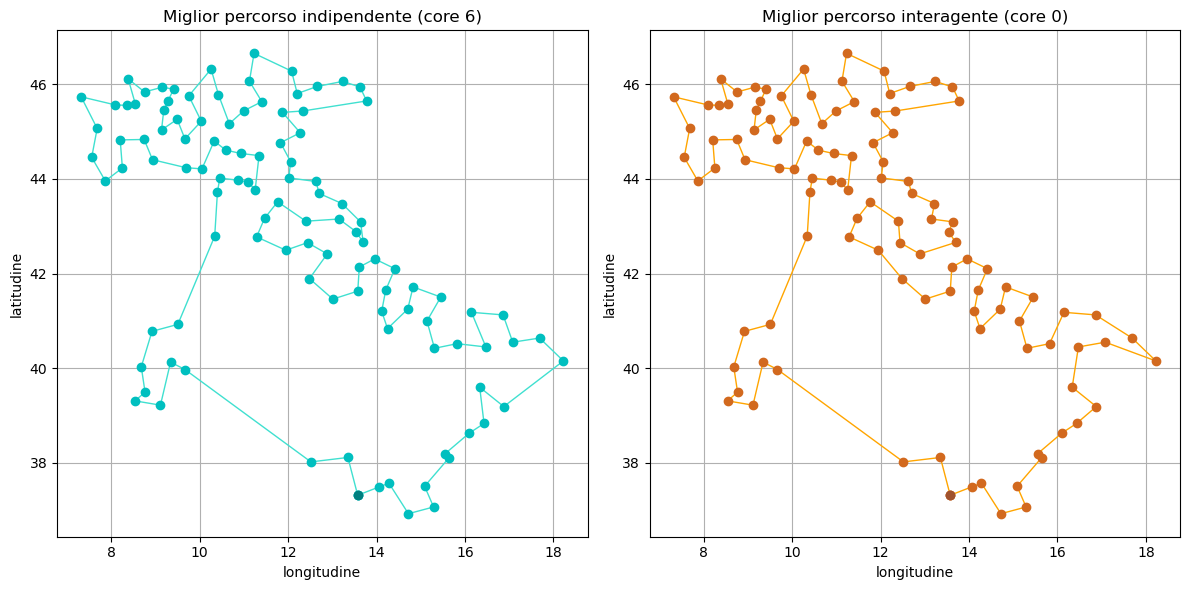

In [2]:
# grafici del percorso
import numpy as np
import matplotlib.pyplot as plt

# -- carico i punti random  --------------------------------------
data = np.loadtxt("Esercizio10.2/cap_prov_ita.dat")
x = data[:, 0]
y= data[:, 1]

# -- prendo il best individuo e ordino i punti random -------------
with open("Esercizio10.2/OUTPUT/best_paths.dat") as f:
    ordine = np.array(f.readlines()[0].split()[1:], dtype=int)

idx = [i - 1 for i in ordine]
x_ord = x[idx]
y_ord = y[idx]

# -- prendo il best individuo e ordino i punti random -------------
with open("Esercizio10.2/OUTPUT_SOLO/best_paths.dat") as f:
    ordine2 = np.array(f.readlines()[6].split()[1:], dtype=int)

idx2 = [i - 1 for i in ordine2]
x_ord2 = x[idx2]
y_ord2 = y[idx2]

# -- faccio grafici ---------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.plot(np.append(x_ord2, x_ord2[0]), np.append(y_ord2, y_ord2[0]), 'o-', markerfacecolor='c', markeredgecolor='c', color='turquoise', lw=1)
ax1.plot(x[0], y[0],'o',color='teal',zorder=5)
ax1.set_xlabel('longitudine')
ax1.set_ylabel('latitudine')
ax1.set_title('Miglior percorso indipendente (core 6)')
ax1.grid(True)

ax2.plot(np.append(x_ord, x_ord[0]), np.append(y_ord, y_ord[0]), 'o-', markerfacecolor='chocolate', markeredgecolor='chocolate', color='orange', lw=1)
ax2.plot(x[0], y[0],'o',color='sienna',zorder=5)
ax2.set_xlabel('longitudine')
ax2.set_ylabel('latitudine')
ax2.set_title('Miglior percorso interagente (core 0)')
ax2.grid(True)

plt.tight_layout()
plt.show()

Il grafico a sinistra mostra il miglior percorso trovato utilizzando processi indipendenti (core 6), mentre quello a destra riporta il risultato ottenuto con i processi interagenti (viene mostrato il core 0 a titolo di esempio, dato che tutti i processi convergono allo stesso valore). Entrambi i tracciati sono privi di incroci e mostrano una forma che ricorda vagamente la penisola italiana, segno che entrambi gli approcci hanno trovato un buon minimo locale. Le differenze visive tra i due sono contenute, quindi il vantaggio della strategia interagente emerge più dal confronto numerico che dall'ispezione grafica.

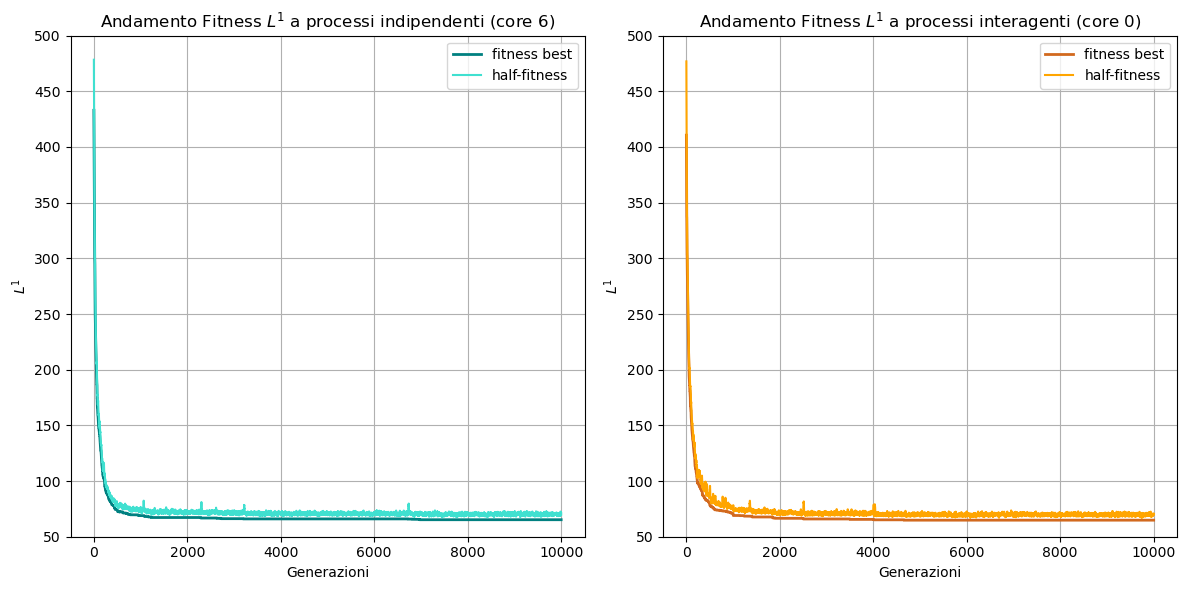

In [3]:
# grafici fitness e half-fitness

# -- carico fitness e half-fitness -----------------------------------------------
fitness = np.loadtxt("Esercizio10.2/OUTPUT/Fitness_capo0.dat")
fitness2 = np.loadtxt("Esercizio10.2/OUTPUT_SOLO/Fitness_capo6.dat")
step = np.arange(1, len(fitness) + 1)

halffitness = np.loadtxt("Esercizio10.2/OUTPUT/HalfFitness_capo0.dat")
halffitness2 = np.loadtxt("Esercizio10.2/OUTPUT_SOLO/HalfFitness_capo6.dat")


# -- faccio grafici ---------------------------------------------------------------------

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax2.plot(step, fitness, '-', color='chocolate', label='fitness best', lw=2)
ax2.plot(step, halffitness, '-', color='orange', label='half-fitness')
ax2.set_xlabel('Generazioni')
ax2.set_ylabel('$L^1$')
ax2.set_title('Andamento Fitness $L^1$ a processi interagenti (core 0)')
ax2.legend()
ax2.grid(True)
ax2.set_ylim(50, 500)

ax1.plot(step, fitness2, '-', color='teal', label='fitness best', lw=2)
ax1.plot(step, halffitness2, '-', color='turquoise', label='half-fitness')
ax1.set_xlabel('Generazioni')
ax1.set_ylabel('$L^1$')
ax1.set_title('Andamento Fitness $L^1$ a processi indipendenti (core 6)')
ax1.legend()
ax1.grid(True)

ax1.set_ylim(50, 500)


plt.tight_layout()
plt.show()

I due grafici mostrano l'andamento della fitness nel corso delle generazioni: a sinistra il core 6 indipendente, a destra il core 0 interagente (riportato a titolo di esempio). In entrambi i casi si riportano la fitness del miglior individuo e la half-fitness, ovvero la fitness media della metà migliore della popolazione. In entrambi i grafici la fitness scende rapidamente nelle prime generazioni, per poi stabilizzarsi progressivamente verso un plateau, segno che l'algoritmo converge verso un minimo.

La differenza più evidente tra i due casi è la presenza, nel grafico interagente, di salti bruschi verso il basso nella fitness in corrispondenza dei multipli di $N_{\text{migr}} = 500$ generazioni, ovvero nei momenti in cui avviene la migrazione. Questi salti indicano che il processo ha ricevuto un individuo migliore da un continente vicino, migliorando istantaneamente la propria soluzione. Tale comportamento è assente nel caso indipendente, dove la curva scende in modo più regolare e privo di discontinuità.